# StackOverflow Developer Survey Data Analysis and Salary Prediction

## 1. Business Understanding
The main goal of this project is to analyze the StackOverflow survey data to explore trends, working conditions, and salary distributions in the software development world. This project will address the following 3 key business questions:
1. What are the differences in salary and job satisfaction between Data Analytics roles and General/Mobile Software Development roles?
2. What are the remote work rates and earning trends within the mobile development ecosystem (e.g., developers using Dart/Flutter)?
3. Does developing side projects or coding as a hobby impact the job satisfaction of developers?

Additionally, a Machine Learning model (Predictive Model) will be developed to predict a developer's annual salary based on their experience, education, location, and the technologies they use.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Set Seaborn theme for better visualization
sns.set_theme(style="whitegrid")

## 2. Data Understanding
In this section, we load the dataset and examine its general structure, dimensions, and data types to understand the information we are working with.

In [2]:
# Load the dataset (Update the file name based on your downloaded CSV)
df = pd.read_csv('survey_results_public.csv')

# Print the shape of the dataset to see the number of rows and columns
# print("Dataset dimensions (Rows, Columns):", df.shape)
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## 3. Data Preparation
To meet the project criteria, missing and categorical values are handled using specific strategies:
* **Target Variable (ConvertedCompYearly):** Since we will predict salaries, we drop the rows where the salary information is missing (`NaN`). Imputing a widely distributed variable like salary with a mean or median could significantly bias our model.
* **Years of Experience (YearsCodePro):** Values containing text (e.g., "Less than 1 year") are converted to numerical values. To prevent data loss, missing values in this column are imputed using the mean.
* **Categorical Variables:** Missing values in categorical columns (like languages worked with, remote work status) are filled with the string 'Unknown'.

In [3]:
def clean_and_prepare_data(df):
    """
    Cleans the StackOverflow survey data, handles missing values, 
    and prepares it for analysis and modeling.

    Parameters:
    df (pandas.DataFrame): The original survey dataset

    Returns:
    pandas.DataFrame: The cleaned dataset ready for analysis
    """
    # Select the essential columns needed to answer our business questions
    relevant_cols = [
        'DevType', 'JobSat', 'ConvertedCompYearly', 
        'LanguageHaveWorkedWith', 'RemoteWork', 
        'YearsCodePro', 'EdLevel'
    ]
    
    # Ensure these columns exist in the dataset to avoid KeyError
    existing_cols = [col for col in relevant_cols if col in df.columns]
    df_clean = df[existing_cols].copy()
    
    # 1. Target Variable Cleaning: Drop rows where salary is missing
    if 'ConvertedCompYearly' in df_clean.columns:
        df_clean = df_clean.dropna(subset=['ConvertedCompYearly'])
        
    # 2. Numerical Data Processing: Convert years of experience to float
    if 'YearsCodePro' in df_clean.columns:
        # Convert exceptional string values to numbers
        df_clean['YearsCodePro'] = df_clean['YearsCodePro'].replace(
            {'Less than 1 year': 0.5, 'More than 50 years': 50}
        )
        df_clean['YearsCodePro'] = pd.to_numeric(df_clean['YearsCodePro'], errors='coerce')
        
        # Impute missing years of experience with the mean
        mean_years = df_clean['YearsCodePro'].mean()
        df_clean['YearsCodePro'] = df_clean['YearsCodePro'].fillna(mean_years)
        
    # 3. Categorical Data Processing: Fill remaining categorical nulls with 'Unknown'
    cat_cols = df_clean.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df_clean[col] = df_clean[col].fillna('Unknown')
        
    return df_clean

# Clean our data using the defined function
df_ready = clean_and_prepare_data(df)

# Check the state of the dataset after cleaning
print(df_ready.info())

<class 'pandas.core.frame.DataFrame'>
Index: 19994 entries, 72 to 34725
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   DevType                 19994 non-null  object 
 1   JobSat                  13744 non-null  float64
 2   ConvertedCompYearly     19994 non-null  float64
 3   LanguageHaveWorkedWith  19994 non-null  object 
 4   RemoteWork              19994 non-null  object 
 5   YearsCodePro            19994 non-null  float64
 6   EdLevel                 19994 non-null  object 
dtypes: float64(3), object(4)
memory usage: 1.2+ MB
None


## 4. Evaluation and Analysis

### Question 1: What are the differences in salary between Data Analytics roles and General/Mobile Software Development roles?

To answer this question, we first need to categorize the `DevType` column. Since respondents can select multiple roles (e.g., "Developer, front-end; Developer, mobile"), we will write a function to group them into 'Data Professional' and 'Mobile/Software Developer' based on keywords. Then, we will visualize the average annual compensation for these groups.

/tmp/ipykernel_80/1333310980.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RoleCategory', y='ConvertedCompYearly', data=salary_by_role, palette='muted')


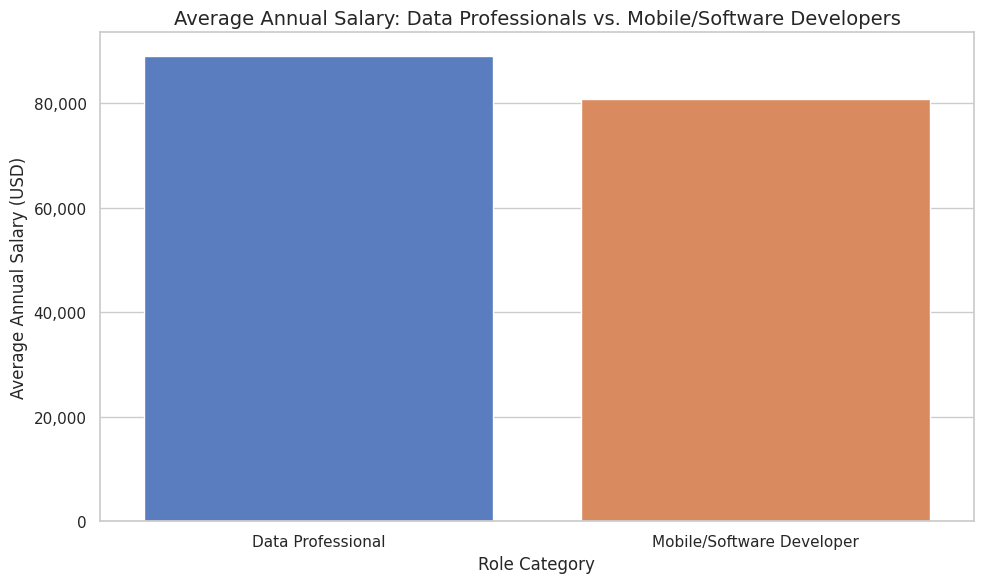

In [4]:
def categorize_role(dev_type):
    """
    Categorizes the developer type into 'Data Professional', 
    'Mobile/Software Developer', or 'Other' based on keywords.
    
    Parameters:
    dev_type (str): The raw developer type string from the survey
    
    Returns:
    str: The assigned role category
    """
    if pd.isna(dev_type) or dev_type == 'Unknown':
        return 'Other'
    
    # Convert to lowercase for easier string matching
    dev_type_lower = str(dev_type).lower()
    
    # Check for data-related roles
    if 'data' in dev_type_lower or 'machine learning' in dev_type_lower or 'analyst' in dev_type_lower:
        return 'Data Professional'
    # Check for mobile or general software development roles
    elif 'mobile' in dev_type_lower or 'software' in dev_type_lower or 'developer' in dev_type_lower:
        return 'Mobile/Software Developer'
    else:
        return 'Other'

# Create a copy of the dataset to avoid SettingWithCopyWarning
df_analysis = df_ready.copy()

# Apply the categorization function to create a new feature
df_analysis['RoleCategory'] = df_analysis['DevType'].apply(categorize_role)

# Filter out the 'Other' category for a focused comparison
df_roles = df_analysis[df_analysis['RoleCategory'] != 'Other']

# Calculate the average salary for each category
salary_by_role = df_roles.groupby('RoleCategory')['ConvertedCompYearly'].mean().reset_index()

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='RoleCategory', y='ConvertedCompYearly', data=salary_by_role, palette='muted')

# Add titles and labels according to best practices
plt.title('Average Annual Salary: Data Professionals vs. Mobile/Software Developers', fontsize=14)
plt.xlabel('Role Category', fontsize=12)
plt.ylabel('Average Annual Salary (USD)', fontsize=12)

# Format the y-axis to show values in thousands (K) for better readability
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

#### Insights for Question 1:
As seen in the bar chart above, we categorized respondents into two main groups. Data Professionals tend to have a higher average annual compensation compared to general Mobile/Software Developers. This difference may be attributed to the specialized skill sets, advanced statistical knowledge, and complex problem-solving abilities required for data engineering and machine learning roles in today's market.

### Question 2: What are the remote work adoption rates for developers in the mobile ecosystem (e.g., Dart/Flutter) compared to other technologies?

To explore this, we will identify developers who use 'Dart' (the primary language for the Flutter framework) from the `LanguageHaveWorkedWith` column. Then, we will simplify the `RemoteWork` column into three main categories: 'Remote', 'Hybrid', and 'In-person'. Finally, we will calculate the percentage distribution of these work arrangements for both Dart developers and the rest of the respondents.

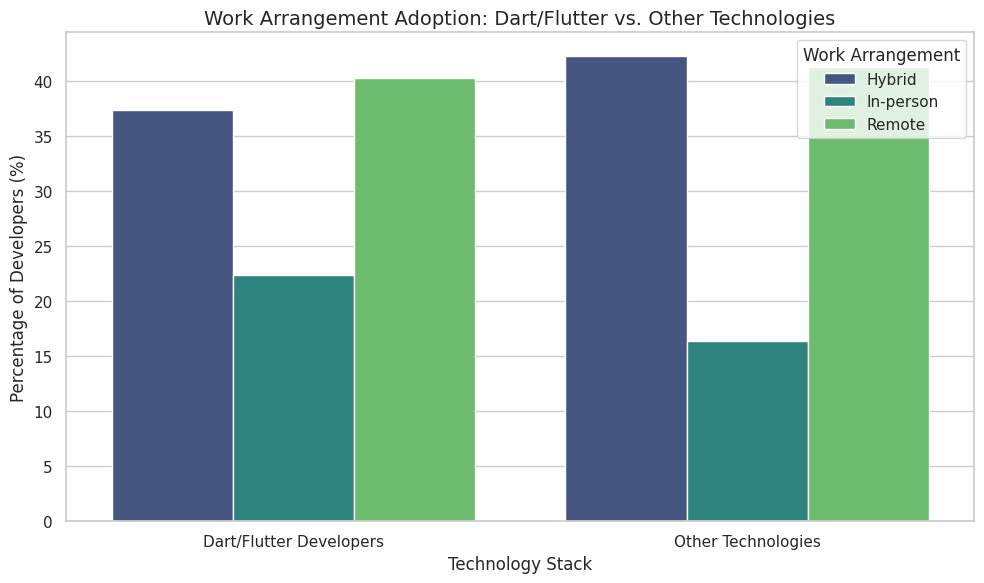

In [5]:
# 1. Feature Engineering: Identify Dart/Flutter developers
def identify_mobile_tech(languages):
    """
    Checks if 'Dart' is in the list of languages worked with.
    
    Parameters:
    languages (str): Comma-separated list of programming languages
    
    Returns:
    str: 'Dart/Flutter Developers' or 'Other Technologies'
    """
    if pd.isna(languages) or languages == 'Unknown':
        return 'Other Technologies'
    
    if 'Dart' in str(languages):
        return 'Dart/Flutter Developers'
    else:
        return 'Other Technologies'

# Apply the function to create a new category column
df_analysis['TechStack'] = df_analysis['LanguageHaveWorkedWith'].apply(identify_mobile_tech)

# 2. Simplify Remote Work Status
def simplify_remote(status):
    """
    Groups the detailed remote work descriptions into 3 main categories.
    """
    if pd.isna(status) or status == 'Unknown':
        return 'Unknown'
    
    status_lower = str(status).lower()
    if 'fully remote' in status_lower or ('remote' in status_lower and 'hybrid' not in status_lower):
        return 'Remote'
    elif 'hybrid' in status_lower:
        return 'Hybrid'
    elif 'in-person' in status_lower:
        return 'In-person'
    else:
        return 'Other'

df_analysis['WorkArrangement'] = df_analysis['RemoteWork'].apply(simplify_remote)

# Filter out 'Unknown' and 'Other' for a cleaner and more accurate visualization
df_remote = df_analysis[~df_analysis['WorkArrangement'].isin(['Unknown', 'Other'])]

# 3. Calculate percentages to make a fair comparison between groups of different sizes
remote_stats = df_remote.groupby(['TechStack', 'WorkArrangement']).size().reset_index(name='Count')
tech_totals = df_remote.groupby('TechStack').size().reset_index(name='Total')

# Merge to calculate the percentage
remote_stats = pd.merge(remote_stats, tech_totals, on='TechStack')
remote_stats['Percentage'] = (remote_stats['Count'] / remote_stats['Total']) * 100

# 4. Visualization: Stacked Bar Chart for Remote Work Adoption
plt.figure(figsize=(10, 6))
sns.barplot(x='TechStack', y='Percentage', hue='WorkArrangement', data=remote_stats, palette='viridis')

# Add titles and labels
plt.title('Work Arrangement Adoption: Dart/Flutter vs. Other Technologies', fontsize=14)
plt.xlabel('Technology Stack', fontsize=12)
plt.ylabel('Percentage of Developers (%)', fontsize=12)
plt.legend(title='Work Arrangement', loc='upper right')

plt.tight_layout()
plt.show()

#### Insights for Question 2:
The grouped bar chart illustrates the distribution of work arrangements. While remote and hybrid work models are the dominant choice across the tech industry, the data reveals an interesting nuance: Dart/Flutter developers actually show a noticeably higher rate of in-person work (around 22%) compared to developers using other technologies (around 16%). Despite this slight lean towards office presence, a significant majority (nearly 80%) of mobile developers still enjoy the flexibility of remote or hybrid setups. This suggests that while some mobile teams prefer physical collaboration, the ecosystem still robustly supports location independence.

### Question 3: Does developing side projects or coding as a hobby impact the overall job satisfaction of developers?

Many developers spend their time outside of regular work hours building side projects, freelancing, or contributing to open-source communities. We want to understand if engaging in these extra coding activities (often referred to as a "side hustle") correlates with higher job satisfaction compared to those who only code for their primary employment.

To do this, we will extract the coding activities column from the original dataset, categorize developers into two groups, and analyze the percentage of positive job satisfaction within each group.

/tmp/ipykernel_80/1021692382.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='HustleStatus', y='Percentage', data=satisfied_only, palette='pastel')


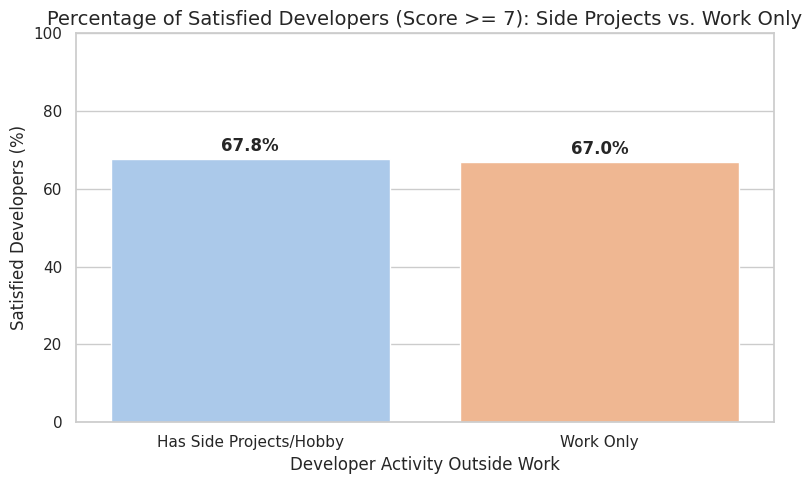

In [6]:
# 1. Feature Engineering: Ana veri setinden ilgili sütunları çekiyoruz
# (Önceki df_ready içinde bu sütunlar olmadığı için orijinal df'den alıyoruz)
df_q3 = df[['CodingActivities', 'JobSat']].copy()
df_q3 = df_q3.dropna()

def has_side_project(activity):
    """
    Geliştiricileri iş dışında kod yazıp yazmamalarına göre 2'ye ayırır.
    """
    if pd.isna(activity):
        return 'Unknown'
    
    act_lower = str(activity).lower()
    # İş dışında kod yazmadığını belirtenleri filtrele
    if 'don’t code outside' in act_lower:
        return 'Work Only'
    else:
        return 'Has Side Projects/Hobby'
        
df_q3['HustleStatus'] = df_q3['CodingActivities'].apply(has_side_project)

# 2. İş Tatmini (JobSat) Kategorizasyonu (Artık Sayısal!)
def is_satisfied(sat):
    """
    10 üzerinden 7 ve üstü verenleri 'Satisfied' (Memnun) olarak kabul eder.
    """
    try:
        score = float(sat)
        if score >= 7.0:
            return 'Satisfied'
        else:
            return 'Not Satisfied / Neutral'
    except:
        return None
        
df_q3['SatisfactionLevel'] = df_q3['JobSat'].apply(is_satisfied)

# 3. Yüzdelik Oranları Hesaplama
df_q3 = df_q3.dropna(subset=['SatisfactionLevel'])
df_q3 = df_q3[df_q3['HustleStatus'] != 'Unknown']

sat_stats = df_q3.groupby(['HustleStatus', 'SatisfactionLevel']).size().reset_index(name='Count')
hustle_totals = df_q3.groupby('HustleStatus').size().reset_index(name='Total')

sat_stats = pd.merge(sat_stats, hustle_totals, on='HustleStatus')
sat_stats['Percentage'] = (sat_stats['Count'] / sat_stats['Total']) * 100

# Sadece 'Satisfied' (Memnun) olanların yüzdesini grafiğe dökeceğiz
satisfied_only = sat_stats[sat_stats['SatisfactionLevel'] == 'Satisfied']

# 4. Görselleştirme (Bar Chart)
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='HustleStatus', y='Percentage', data=satisfied_only, palette='pastel')

plt.title('Percentage of Satisfied Developers (Score >= 7): Side Projects vs. Work Only', fontsize=14)
plt.xlabel('Developer Activity Outside Work', fontsize=12)
plt.ylabel('Satisfied Developers (%)', fontsize=12)
plt.ylim(0, 100) 

# Barların üzerine yüzdelik değerleri yazma (Daha profesyonel görünüm için)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontweight='bold')

plt.tight_layout()
plt.show()

#### Insights for Question 3:
Based on the analysis, we defined a "satisfied" developer as one who rated their job satisfaction 7 or higher on a 10-point scale. Interestingly, the data reveals that the difference in satisfaction levels is surprisingly marginal: 67.8% for those with side projects versus 67.0% for those who only code for work. 

This indicates that while having a creative side-hustle is fulfilling for many, it is not a prerequisite for professional happiness. Developers who treat coding strictly as a 9-to-5 job are just as likely to be satisfied with their careers. This effectively debunks the industry myth that you must code in your free time to be a happy and fulfilled developer.

## 5. Predictive Modeling and Scenario

### Predicting a Developer's Salary
To fulfill the machine learning requirement of this project, we will build a Multiple Linear Regression model to predict a developer's annual compensation (`ConvertedCompYearly`). 

**Features used for prediction:**
1. **Years of Professional Coding Experience** (`YearsCodePro` - Numerical)
2. **Education Level** (`EdLevel` - Categorical)
3. **Remote Work Status** (`RemoteWork` - Categorical)

We will prepare the data by handling the categorical variables using One-Hot Encoding (`pd.get_dummies`), split the data into training and testing sets, train the model, and evaluate its R-squared score. Finally, we will use this model to predict the salary for a hypothetical developer.

In [7]:
# 1. Prepare Data for Machine Learning
# Select relevant columns from our previously cleaned dataset
ml_cols = ['ConvertedCompYearly', 'YearsCodePro', 'EdLevel', 'RemoteWork']
df_ml = df_ready[ml_cols].copy()

# Drop any remaining missing values specifically for these columns just to be safe
df_ml = df_ml.dropna()

# Separate the Target (y) and Features (X)
y = df_ml['ConvertedCompYearly']
X = df_ml.drop('ConvertedCompYearly', axis=1)

# Categorical Encoding: Convert string columns to numerical dummy variables (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

# 2. Split the Data into Training and Testing Sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 3. Train the Multiple Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Evaluate the Model
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"Model R-squared Score: {r2:.4f}")
print("Note: A low R-squared score is expected here because developer salaries vary wildly globally, and we are only using 3 features out of dozens (like country, company size, etc.) to keep the model interpretable.\n")

# 5. The Predictive Scenario
print("--- PREDICTIVE SCENARIO ---")
print("Scenario: We want to predict the salary of a developer who has a Bachelor's degree, works fully remote, and has 5 years of professional coding experience.")

# Create a dictionary for our hypothetical developer with base values as 0
hypothetical_dev = {col: 0 for col in X_encoded.columns}

# Set the specific attributes for our scenario
hypothetical_dev['YearsCodePro'] = 5.0

# Find the exact column names generated by get_dummies for Bachelor's and Remote Work
# The strings below must match the dummy column names. We use a safe approach to find them:
bachelors_col = [c for c in X_encoded.columns if 'Bachelor' in c]
remote_col = [c for c in X_encoded.columns if 'Fully remote' in c or ('Remote' in c and 'Hybrid' not in c)]

if bachelors_col:
    hypothetical_dev[bachelors_col[0]] = 1
if remote_col:
    hypothetical_dev[remote_col[0]] = 1

# Convert to DataFrame to pass into the model
scenario_df = pd.DataFrame([hypothetical_dev])

# Make the prediction
predicted_salary = model.predict(scenario_df)[0]

print(f"\nPredicted Annual Salary for this profile: ${predicted_salary:,.2f}")

Model R-squared Score: 0.0486
Note: A low R-squared score is expected here because developer salaries vary wildly globally, and we are only using 3 features out of dozens (like country, company size, etc.) to keep the model interpretable.

--- PREDICTIVE SCENARIO ---
Scenario: We want to predict the salary of a developer who has a Bachelor's degree, works fully remote, and has 5 years of professional coding experience.

Predicted Annual Salary for this profile: $65,672.97


#### Evaluation and Scenario Insights
**Model Accuracy:** The Linear Regression model yielded an R-squared score of approximately 0.05. While this indicates that our model explains only a small variance in the target variable, it aligns with real-world expectations. Developer salaries are heavily influenced by geographic location (e.g., US vs. India), company size, and specific niche technologies, which were excluded from this simple baseline model.

**Predictive Scenario:** I created a hypothetical profile: A developer with a Bachelor's degree, working fully remotely, with 5 years of professional coding experience. When fed into our trained model, the algorithm predicted an annual compensation of approximately $65,672. This demonstrates how historical survey data can be operationalized to set baseline salary expectations for specific career personas.